In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_excel('../data/Online Retail.xlsx',
                   dtype={'CustomerID': str},
                   engine='openpyxl')

print(f"Dataset loaded!")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded!
Rows: 541,909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
# Show the first 5 rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
# type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Count null values in each column
print("Missing values in each column: ")
print(df.isnull().sum())

Missing values in each column: 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# basic statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [7]:
# Adding a revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Total revenue in raw dataset
total = df[df['Revenue'] > 0]['Revenue'].sum()
print(f"Total revenue in raw data: {total:,.2f}")
print(f"Total unique customers: {df['CustomerID'].nunique()}")
print(f"Data range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Total revenue in raw data: 10,666,684.54
Total unique customers: 4372
Data range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [8]:
# drop the rows where customerID is empty as it can't be used

before = len(df)
df = df.dropna(subset=['CustomerID'])
after = len(df)

print(f"Removed {before - after} rows with no CustomerID")
print(f"Rows remaining: {after}")

Removed 135080 rows with no CustomerID
Rows remaining: 406829


In [9]:
# Items with price 0 are test enties, so dropping them

before = len(df)
df = df[df['UnitPrice'] > 0]
after = len(df)

print(f"Removed {before - after} rows with zero/negative price")
print(f"Rows remaining: {after}")

Removed 40 rows with zero/negative price
Rows remaining: 406789


In [10]:
# Cancelled invoices start with C are not of any use

before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
after = len(df)

print(f"Removed {before - after} cancelled orders")
print(f"Rows remaining: {after}")

Removed 8905 cancelled orders
Rows remaining: 397884


In [11]:
# Removing identical rows

before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Removed {before - after} duplicate rows")
print(f"Rows remaining: {after}")

Removed 5192 duplicate rows
Rows remaining: 392692


In [12]:
# Convert InvoiceDate from text to date format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Date column fixed!")
print(f"Latest date:  {df['InvoiceDate'].max().date()}")

Date column fixed!
Latest date:  2011-12-09


In [13]:
print("=== FINAL DATA CHECK ===")
print(f"Total rows:              {len(df):,}")
print(f"Total unique customers:  {df['CustomerID'].nunique():,}")
print(f"Missing values left:     {df.isnull().sum().sum()}")
print(f"Negative quantities:     {(df['Quantity'] < 0).sum():,}")
print(f"Total revenue:           {df[df['Revenue'] > 0]['Revenue'].sum():,.2f}")

=== FINAL DATA CHECK ===
Total rows:              392,692
Total unique customers:  4,338
Missing values left:     0
Negative quantities:     0
Total revenue:           8,887,208.89


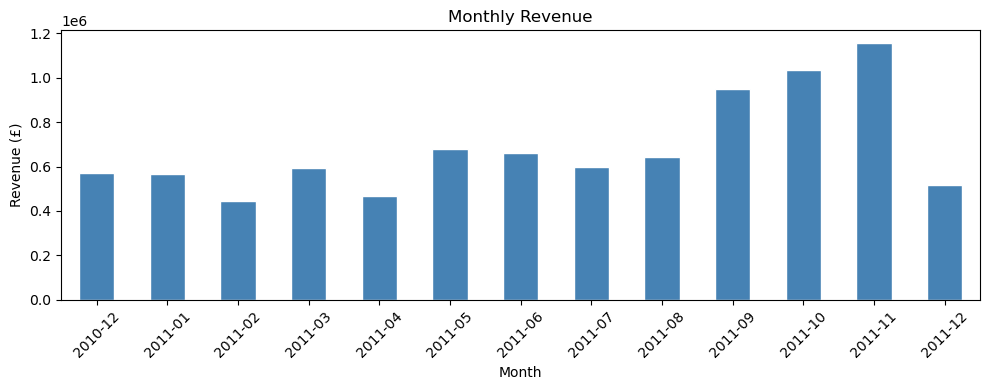

In [14]:
# Group revenue by month and plot it
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df[df['Revenue'] > 0].groupby('YearMonth')['Revenue'].sum()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Save cleaned data so we can use it further
# We save as CSV because it loads much faster than Excel

df.to_csv('../data/cleaned_transactions.csv', index=False)

print("Saved! File: data/cleaned_transactions.csv")
print(f"Final row count: {len(df):,}")
print(f"Final columns: {df.columns.tolist()}")


Saved! File: data/cleaned_transactions.csv
Final row count: 392,692
Final columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'YearMonth']
